In [4]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sqlalchemy import create_engine
from sklearn.ensemble import VotingClassifier

print("All libraries loaded!")

All libraries loaded!


In [5]:
df = pd.read_csv("/Users/virali/Documents/burnout_project/StressLevelDataset.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (1100, 21)

First 5 rows:


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [6]:
print("Dataset Info:")
print(df.info())

print("\nBasic Statistics:")
print(df.describe())

print("\nTarget Variable Distribution:")
print(df['stress_level'].value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load         

Missing Values:
anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
academic_performance            0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
dtype: int64

Duplicate Rows: 0


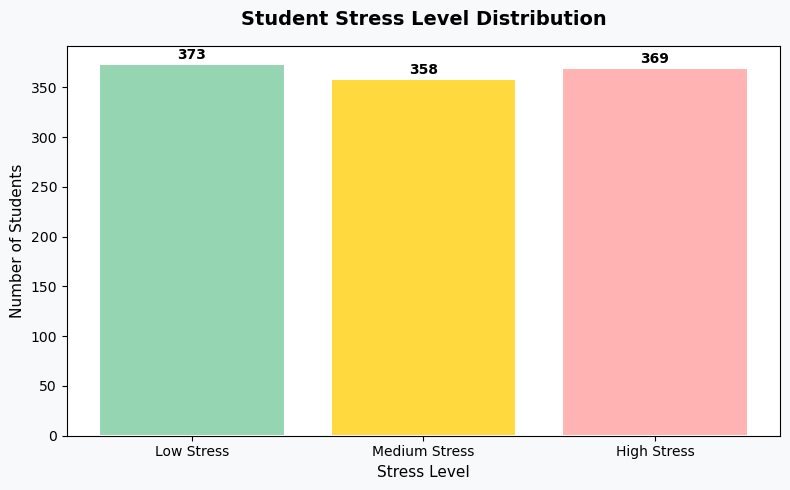

In [7]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

# Stress Level Distribution
fig, ax = plt.subplots(figsize=(8,5), facecolor='#f8f9fa')
bars = ax.bar(['Low Stress', 'Medium Stress', 'High Stress'],
               df['stress_level'].value_counts().sort_index(),
               color=['#95d5b2', '#ffd93d', '#ffb3b3'],
               edgecolor='white', linewidth=1.5)
ax.set_facecolor('#ffffff')
ax.set_title('Student Stress Level Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Stress Level', fontsize=11)
ax.set_ylabel('Number of Students', fontsize=11)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

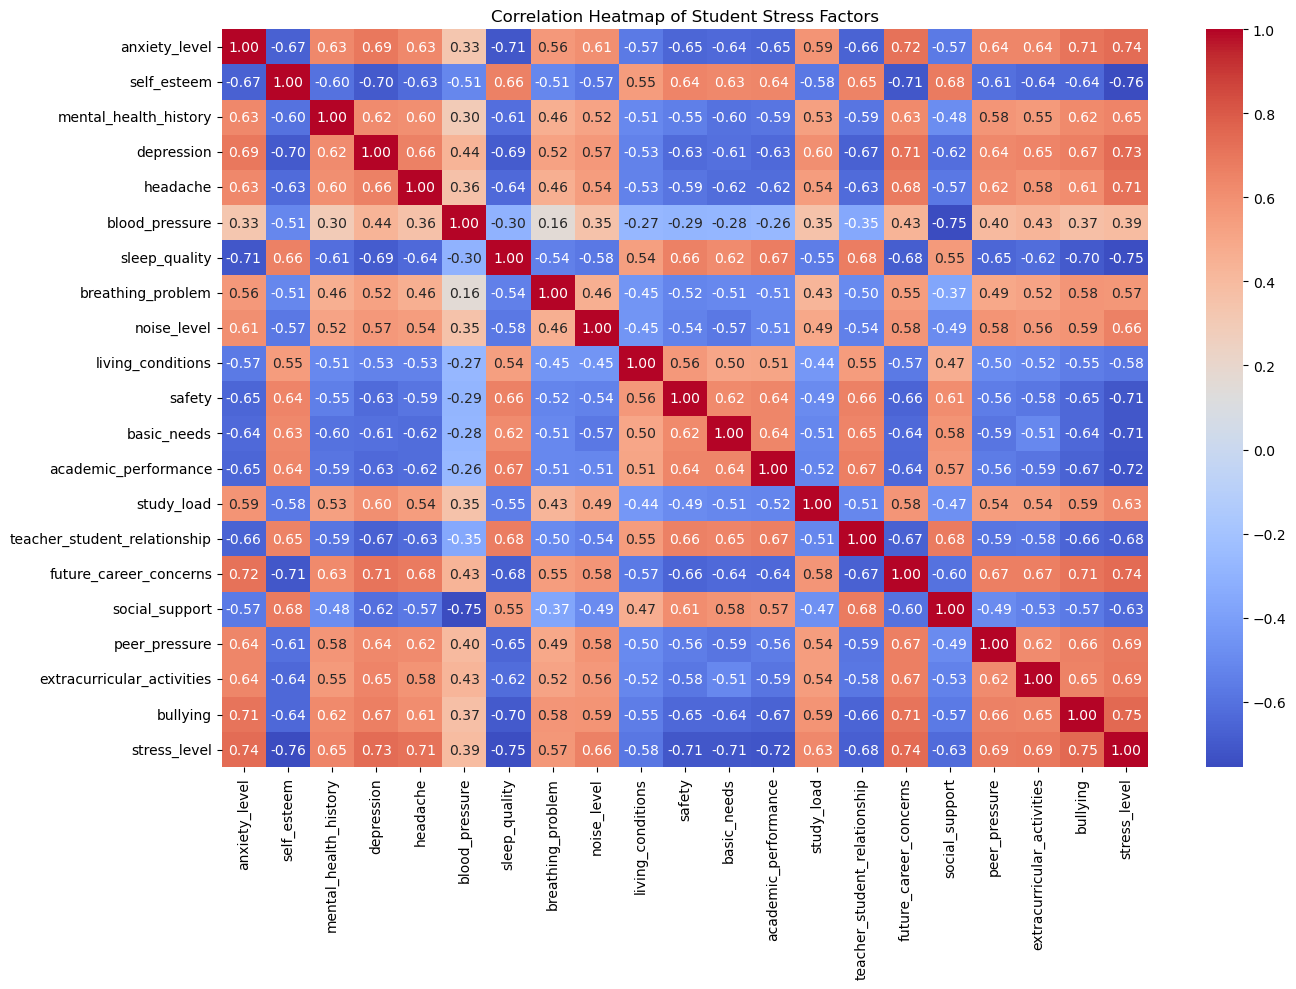

In [8]:
# Correlation Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Student Stress Factors')
plt.tight_layout()
plt.show()

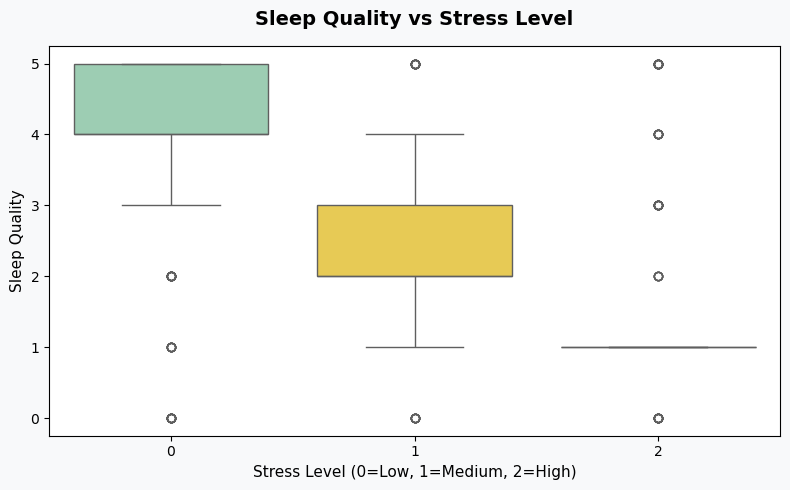

In [9]:
#Sleep Quality vs Stress Level
fig, ax = plt.subplots(figsize=(8,5), facecolor='#f8f9fa')
sns.boxplot(x='stress_level', y='sleep_quality', data=df,
            hue='stress_level',
            palette={0: '#95d5b2', 1: '#ffd93d', 2: '#ffb3b3'},
            legend=False, ax=ax)
ax.set_facecolor('#ffffff')
ax.set_title('Sleep Quality vs Stress Level', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Stress Level (0=Low, 1=Medium, 2=High)', fontsize=11)
ax.set_ylabel('Sleep Quality', fontsize=11)
plt.tight_layout()
plt.show()

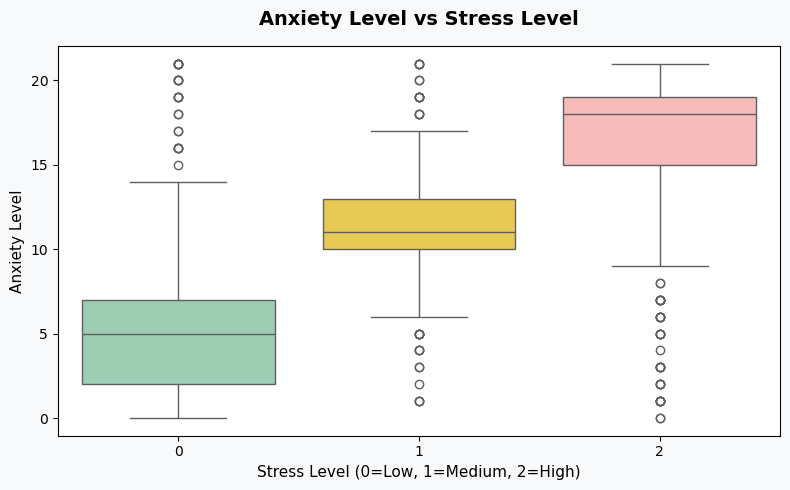

In [10]:
#Anxiety Level vs Stress Level
fig, ax = plt.subplots(figsize=(8,5), facecolor='#f8f9fa')
sns.boxplot(x='stress_level', y='anxiety_level', data=df,
            hue='stress_level',
            palette={0: '#95d5b2', 1: '#ffd93d', 2: '#ffb3b3'},
            legend=False, ax=ax)
ax.set_facecolor('#ffffff')
ax.set_title('Anxiety Level vs Stress Level', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Stress Level (0=Low, 1=Medium, 2=High)', fontsize=11)
ax.set_ylabel('Anxiety Level', fontsize=11)
plt.tight_layout()
plt.show()

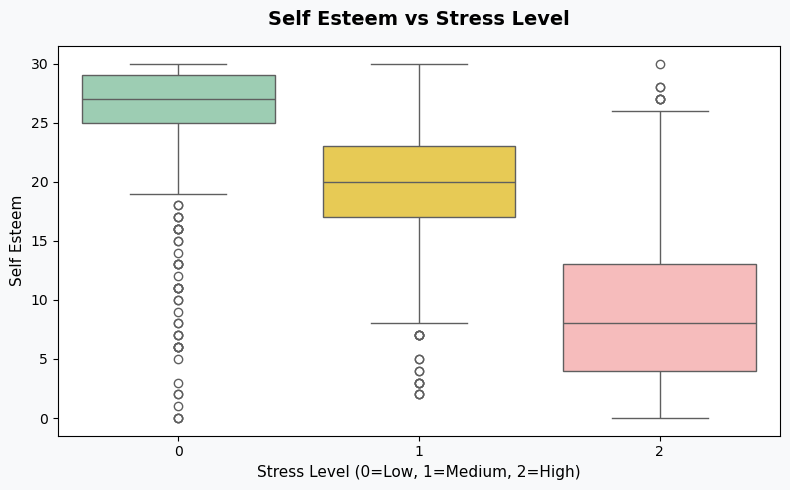

In [11]:
# Self Esteem vs Stress Level
fig, ax = plt.subplots(figsize=(8,5), facecolor='#f8f9fa')
sns.boxplot(x='stress_level', y='self_esteem', data=df,
            hue='stress_level',
            palette={0: '#95d5b2', 1: '#ffd93d', 2: '#ffb3b3'},
            legend=False, ax=ax)
ax.set_facecolor('#ffffff')
ax.set_title('Self Esteem vs Stress Level', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Stress Level (0=Low, 1=Medium, 2=High)', fontsize=11)
ax.set_ylabel('Self Esteem', fontsize=11)
plt.tight_layout()
plt.show()

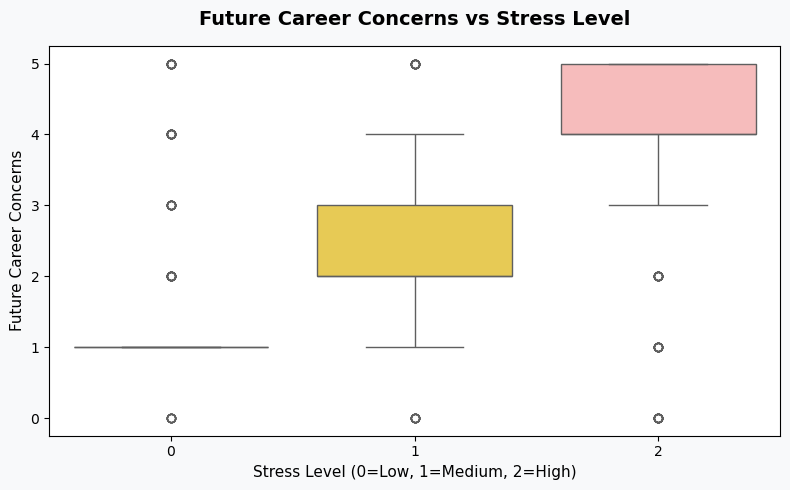

In [12]:
# Future Career Concerns vs Stress Level
fig, ax = plt.subplots(figsize=(8,5), facecolor='#f8f9fa')
sns.boxplot(x='stress_level', y='future_career_concerns', data=df,
            hue='stress_level',
            palette={0: '#95d5b2', 1: '#ffd93d', 2: '#ffb3b3'},
            legend=False, ax=ax)
ax.set_facecolor('#ffffff')
ax.set_title('Future Career Concerns vs Stress Level', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Stress Level (0=Low, 1=Medium, 2=High)', fontsize=11)
ax.set_ylabel('Future Career Concerns', fontsize=11)
plt.tight_layout()
plt.show()

In [13]:
# Feature Engineering
df_fe = df.copy()

# Feature 1: Mental Load Score (academic pressure + study load + career concerns)
df_fe['mental_load'] = df_fe['study_load'] + df_fe['future_career_concerns'] + df_fe['academic_performance']

# Feature 2: Social Vulnerability (bullying + peer pressure - social support)
df_fe['social_vulnerability'] = df_fe['bullying'] + df_fe['peer_pressure'] - df_fe['social_support']

# Feature 3: Physical Stress Index (blood pressure + headache + breathing_problem - sleep_quality)
df_fe['physical_stress'] = df_fe['blood_pressure'] + df_fe['headache'] + df_fe['breathing_problem'] - df_fe['sleep_quality']

print("New features added!")
print(df_fe[['mental_load', 'social_vulnerability', 'physical_stress']].describe())

New features added!
       mental_load  social_vulnerability  physical_stress
count  1100.000000           1100.000000      1100.000000
mean      8.043636              3.470000         4.783636
std       1.914911              3.411964         4.000740
min       1.000000             -1.000000        -1.000000
25%       7.000000              0.000000         1.000000
50%       8.000000              3.000000         4.000000
75%       9.000000              7.000000         9.000000
max      14.000000             10.000000        12.000000


In [14]:
# Check correlation with stress level
print("Correlation with stress_level:")
print(df_fe[['mental_load', 'social_vulnerability', 'physical_stress', 'stress_level']].corr()['stress_level'])

Correlation with stress_level:
mental_load             0.496284
social_vulnerability    0.819807
physical_stress         0.824342
stress_level            1.000000
Name: stress_level, dtype: float64


In [15]:
from sqlalchemy import create_engine

engine = create_engine('postgresql://virali@localhost:5432/burnout_project')

with engine.connect() as conn:
    print("Connected to PostgreSQL!")

df.to_sql('student_stress', engine, if_exists='replace', index=False)
print("Data loaded into PostgreSQL successfully!")

Connected to PostgreSQL!
Data loaded into PostgreSQL successfully!


In [16]:
query1 = pd.read_sql("SELECT stress_level, COUNT(*) as count FROM student_stress GROUP BY stress_level ORDER BY stress_level", engine)
print("Students per stress level:")
print(query1)

query2 = pd.read_sql("SELECT stress_level, ROUND(AVG(anxiety_level)::numeric, 2) as avg_anxiety, ROUND(AVG(sleep_quality)::numeric, 2) as avg_sleep FROM student_stress GROUP BY stress_level ORDER BY stress_level", engine)
print("\nAverage anxiety and sleep by stress level:")
print(query2)

Students per stress level:
   stress_level  count
0             0    373
1             1    358
2             2    369

Average anxiety and sleep by stress level:
   stress_level  avg_anxiety  avg_sleep
0             0         5.43       4.13
1             1        11.43       2.53
2             2        16.40       1.30


In [17]:
df2 = pd.read_csv("/Users/virali/Documents/burnout_project/Stress_Dataset.csv")
df2.to_sql('student_stress_survey', engine, if_exists='replace', index=False)
print("Second dataset loaded into PostgreSQL!")
print("Shape:", df2.shape)

# Query second table
query3 = pd.read_sql("""
    SELECT "Which type of stress do you primarily experience?", 
           COUNT(*) as count
    FROM student_stress_survey 
    GROUP BY "Which type of stress do you primarily experience?"
""", engine)
print("\nStress types from survey dataset:")
print(query3)

Second dataset loaded into PostgreSQL!
Shape: (843, 26)

Stress types from survey dataset:
   Which type of stress do you primarily experience?  count
0  Eustress (Positive Stress) - Stress that motiv...    768
1  No Stress - Currently experiencing minimal to ...     43
2  Distress (Negative Stress) - Stress that cause...     32


In [18]:
X = df.drop('stress_level', axis=1)
y = df['stress_level']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.ensemble import RandomForestClassifier
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_temp.fit(X_scaled, y)

importances = pd.Series(rf_temp.feature_importances_, index=X.columns)
top12 = importances.sort_values(ascending=False).head(12).index.tolist()
print("Top 12 features selected:")
print(top12)

X_final = df[top12]
X_final_scaled = scaler.fit_transform(X_final)

X_train, X_test, y_train, y_test = train_test_split(X_final_scaled, y, test_size=0.2, random_state=42)
print("\nTraining set:", X_train.shape)
print("Testing set:", X_test.shape)

Top 12 features selected:
['blood_pressure', 'sleep_quality', 'basic_needs', 'safety', 'depression', 'self_esteem', 'academic_performance', 'future_career_concerns', 'social_support', 'anxiety_level', 'extracurricular_activities', 'teacher_student_relationship']

Training set: (880, 12)
Testing set: (220, 12)


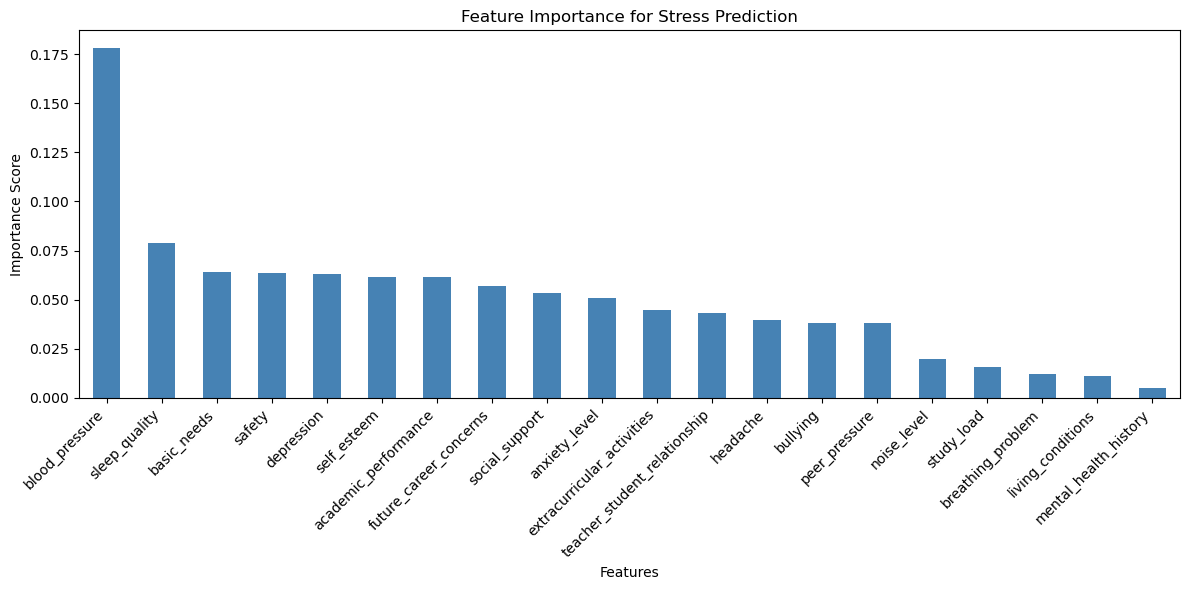

In [19]:
importances.sort_values(ascending=False).plot(kind='bar', figsize=(12,6), color='steelblue')
plt.title('Feature Importance for Stress Prediction')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [20]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr_model.predict(X_test))
print("Logistic Regression Accuracy:", round(lr_acc*100, 2), "%")

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf_model.predict(X_test))
print("Random Forest Accuracy:", round(rf_acc*100, 2), "%")

# SVM
from sklearn.svm import SVC
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)
svm_acc = accuracy_score(y_test, svm_model.predict(X_test))
print("SVM Accuracy:", round(svm_acc*100, 2), "%")

# XGBoost
xgb_model = XGBClassifier(n_estimators=200, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_acc = accuracy_score(y_test, xgb_model.predict(X_test))
print("XGBoost Accuracy:", round(xgb_acc*100, 2), "%")

print("\nBest Model: XGBoost with", round(max(lr_acc, rf_acc, xgb_acc)*100, 2), "% accuracy")

Logistic Regression Accuracy: 87.27 %
Random Forest Accuracy: 86.82 %
SVM Accuracy: 87.73 %
XGBoost Accuracy: 88.18 %

Best Model: XGBoost with 88.18 % accuracy


In [21]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('xgb', XGBClassifier(n_estimators=200, random_state=42))
    ],
    voting='soft'
)

ensemble.fit(X_train, y_train)
ensemble_acc = accuracy_score(y_test, ensemble.predict(X_test))
print("Ensemble Accuracy:", round(ensemble_acc*100, 2), "%")

Ensemble Accuracy: 88.64 %


In [22]:
from sklearn.metrics import classification_report, confusion_matrix

# Classification Report for all models
print("LOGISTIC REGRESSION")
print(classification_report(y_test, lr_model.predict(X_test), target_names=['Low', 'Medium', 'High']))

print("RANDOM FOREST")
print(classification_report(y_test, rf_model.predict(X_test), target_names=['Low', 'Medium', 'High']))

print("SVM")
print(classification_report(y_test, svm_model.predict(X_test), target_names=['Low', 'Medium', 'High']))

print("XGBOOST")
print(classification_report(y_test, xgb_model.predict(X_test), target_names=['Low', 'Medium', 'High']))

print("ENSEMBLE (FINAL MODEL)")
print(classification_report(y_test, ensemble.predict(X_test), target_names=['Low', 'Medium', 'High']))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

         Low       0.87      0.88      0.88        76
      Medium       0.91      0.88      0.90        73
        High       0.84      0.86      0.85        71

    accuracy                           0.87       220
   macro avg       0.87      0.87      0.87       220
weighted avg       0.87      0.87      0.87       220

RANDOM FOREST
              precision    recall  f1-score   support

         Low       0.82      0.89      0.86        76
      Medium       0.89      0.89      0.89        73
        High       0.91      0.82      0.86        71

    accuracy                           0.87       220
   macro avg       0.87      0.87      0.87       220
weighted avg       0.87      0.87      0.87       220

SVM
              precision    recall  f1-score   support

         Low       0.83      0.89      0.86        76
      Medium       0.93      0.88      0.90        73
        High       0.88      0.86    

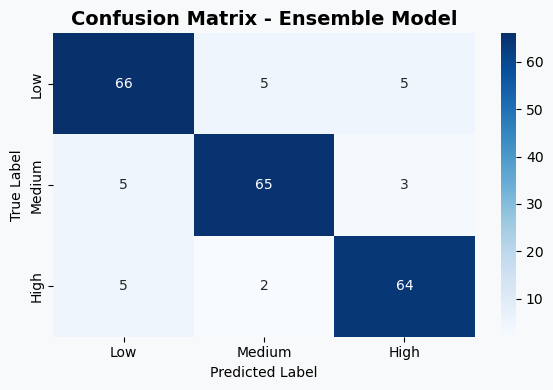


High stress recall: 90.1%
High stress misclassified: 7 out of 71


In [23]:
cm = confusion_matrix(y_test, ensemble.predict(X_test))
fig, ax = plt.subplots(figsize=(6,4), facecolor='#f8f9fa')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low','Medium','High'],
            yticklabels=['Low','Medium','High'])
ax.set_title('Confusion Matrix - Ensemble Model', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()
print(f"\nHigh stress recall: {round(cm[2][2]/cm[2].sum()*100,1)}%")
print(f"High stress misclassified: {cm[2][0]+cm[2][1]} out of {cm[2].sum()}")

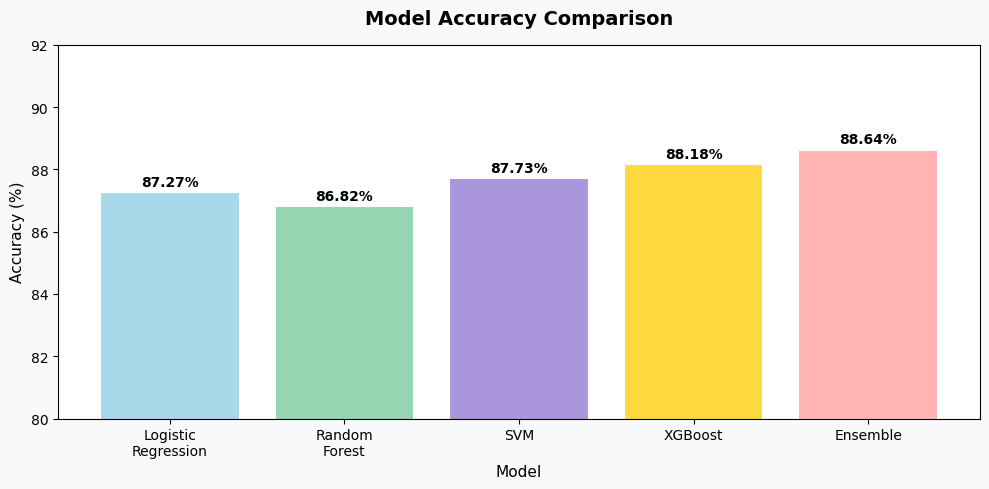

In [24]:
fig, ax = plt.subplots(figsize=(10,5), facecolor='#f8f9fa')
model_names = ['Logistic\nRegression', 'Random\nForest', 'SVM', 'XGBoost', 'Ensemble']
accs = [lr_acc*100, rf_acc*100, svm_acc*100, xgb_acc*100, ensemble_acc*100]
bars = ax.bar(model_names, accs,
              color=['#a8d8ea', '#95d5b2', '#aa96da', '#ffd93d', '#ffb3b3'],
              edgecolor='white', linewidth=1.5)
ax.set_facecolor('#ffffff')
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_ylim(80, 92)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()